# E2 — MoG40 (2D)

**Target.** $V(x) = -\tfrac1\beta\log\sum_{k=1}^{40} e^{-\|x-\mu_k\|^2/2}$, so $\pi\propto e^{-\beta V}$ is an equal-weight mixture of $\mathcal N(\mu_k, I_2)$ (the $1/\beta$ prefactor is what makes the barriers right: $\beta\Delta V = d^2/8-\log 2$ between modes at distance $d$). Modes $\mu_k\sim\mathrm{Unif}([-40,40]^2)$, frozen from `default_rng(0)`. All particles start at $\mu_0+0.5\,\xi$; partition = nearest-mode Voronoi, $p^\star_k = 1/40$.

In [1]:
EXPERIMENT = "mog40"
import os, sys, math, time, json
sys.path.insert(0, os.path.abspath(".."))
from src.gpu_guard import select_gpu
select_gpu(int(os.environ.get("JCP_GPU", "4")))
import torch
assert torch.cuda.device_count() == 1
torch.set_default_dtype(torch.float64)
import numpy as np
import pandas as pd

from src import config as C
from src.experiments import (build_e2, make_sampler_factory,
                             make_batched_factory, make_metrics)
from src.runner import (run_experiment_batched, run_one, refine_dt,
                        quadrature_refinement, write_timeseries_csv,
                        write_summary_csv, write_manifest,
                        ula_first_passage, hardware_manifest)
from src.samplers import tune_ladder
from src.certificate import make_phi_family, certificate_grid, certificate_importance
from src.plotting import metric_grid

DEV = "cuda"
RESULTS = os.path.abspath(os.path.join("..", "results", EXPERIMENT))
FIGURES = os.path.abspath(os.path.join("..", "figures", EXPERIMENT))
os.makedirs(RESULTS, exist_ok=True); os.makedirs(FIGURES, exist_ok=True)
exp = build_e2(device=DEV)
cfg = exp.cfg
print(f"experiment={cfg.name}  d={cfg.d}  N={cfg.n_particles}  T={cfg.T}  dt0={cfg.dt}")
print(f"beta={cfg.beta}  eps={cfg.eps}  lambda={cfg.lam}  seeds={cfg.seeds}")
print(hardware_manifest())

experiment=mog40  d=2  N=2500  T=100.0  dt0=0.01
beta=8.0  eps=0.125  lambda=1.0  seeds=(0, 1, 2, 3, 4)


{'cpu': 'AMD EPYC 9554 64-Core Processor', 'gpu': 'NVIDIA H200 NVL', 'torch': '2.13.0+cu130', 'cuda': '13.0', 'python': '3.12.13', 'git_sha': '389ecdd9aac0ed35b8e48b00d1cfdfdd534575a0', 'cuda_visible_devices': '7', 'gpu_compute_apps_at_start': ['GPU-c8768979-ae7d-8ca1-a33d-2874c9d21fae, 2229276, 31136 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 2229277, 32040 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 2481832, 1522 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 1766636, 814 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 2229278, 31620 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 1727069, 814 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2229280, 31926 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2487190, 710 MiB']}


In [2]:
np.savetxt(os.path.join(RESULTS, "modes.csv"), exp.pot.mu.cpu().numpy(),
           delimiter=",", header="mu_x,mu_y", comments="")
dists = torch.cdist(exp.pot.mu, exp.pot.mu); dists.fill_diagonal_(float("inf"))
nn = dists.min(dim=1).values.cpu().numpy()
print(f"NN distances: min {nn.min():.2f} median {np.median(nn):.2f} max {nn.max():.2f}"
      "  -> jump radii Unif[4, 15] chosen from this histogram alone")
g = torch.Generator(device=DEV); g.manual_seed(0)
barrier_report = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g),
                                   exp.exit_committed, cfg.dt, int(cfg.T/cfg.dt), C.EPS, g)
barrier_report["kramers_tau_mode0"] = exp.kramers_tau
print(f"ULA committed MFPT {barrier_report['mfpt_estimate']:.0f} vs Kramers "
      f"{exp.kramers_tau:.0f}")

NN distances: min 1.22 median 6.78 max 16.02  -> jump radii Unif[4, 15] chosen from this histogram alone


ULA committed MFPT 1664 vs Kramers 552


## Jump law and Lévy score (closed form)

Deliberately generic annulus law — $r=\rho u_\phi$, $\rho\sim\mathrm{Unif}[4,15]$, $\phi\sim\mathrm{Unif}[0,2\pi)$ — **neither PT nor LSC-CP receives mode locations**. For the Gaussian mixture the $\theta$ and $\rho$ integrals of the score are analytic: with $m_{k\ell}=u_\ell\cdot(x-\mu_k)$,
$$S(x) = -\frac{\lambda}{M_\phi(b-a)}\sum_\ell u_\ell \sum_k e^{\log\omega_k + m_{k\ell}^2/2}\,\sqrt{\tfrac\pi2}\,\mathcal B(m_{k\ell}),$$
with $\mathcal B(m) = F(b\!-\!m)-F(a\!-\!m)+(b\!-\!a)\,\mathrm{erf}(m/\sqrt2)>0$ and $F(z)=z\,\mathrm{erf}(z/\sqrt2)+\sqrt{2/\pi}e^{-z^2/2}$, evaluated by outer-regime branches in which the $O(m)$ parts cancel *analytically* (the naive form has 100% error at $m=30$; the branched form is validated against 3000-digit mpmath and a brute-force 3-D quadrature at $10^{-8}$). Only the periodic $\phi$-trapezoid ($M_\phi$ directions) is numerical — **zero potential evaluations**.

In [3]:
DEFAULT_QUAD = dict(m_phi=C.M_PHI)
phis = make_phi_family(2, [0.0, 0.0], 30.0, DEV)

def cert_e2(m_phi):
    score = exp.make_score(m_phi=m_phi)
    shifts, logw = exp.law.quadrature_shifts(16, 64)
    return certificate_grid(exp.pot, score, shifts, logw, cfg.lam, cfg.beta,
                            phis, [-60.0, -60.0], [60.0, 60.0],
                            n_panels=120, nodes_per_panel=6, chunk=8192)

cert_report = cert_e2(**DEFAULT_QUAD)
print(f"max R = {cert_report['max_residual']:.3e}")
assert cert_report["max_residual"] < 1e-6

max R = 7.817e-13


In [4]:
# PT: geometric ladder beta_k = beta * r^(k-1); K tuned so the post-burn-in
# swap acceptance lands in [0.2, 0.4]
gen = torch.Generator(device=DEV); gen.manual_seed(0)
x0_pilot = exp.init_fn(min(512, cfg.n_particles), gen)
pt_betas, ladder_info = tune_ladder(exp.pot, x0_pilot, cfg.dt, exp.box,
                                    C.BETA, exp.pt_beta_min, pilot_steps=20_000)
print(f"PT ladder: K={ladder_info['K']}  r={ladder_info['r']:.4f}  "
      f"beta_K={pt_betas[-1].item():.4f}  swap acceptance={ladder_info['swap_acceptance']:.3f}"
      f"  band_attained={ladder_info['band_attained']}")

PT ladder: K=2  r=0.0625  beta_K=0.5000  swap acceptance=0.191  band_attained=False


In [5]:
# frozen reference sample (size N), frozen sliced-W2 projections, frozen MMD
# bandwidth (median heuristic on the reference); bias floors from 20
# independent reference pairs. EMC convention: exp(H(p_hat))/K for uniform
# p*, 1 - EJS(p_hat, p*) otherwise -- near 1 is better in both cases.
metrics_fn, floors, aux = make_metrics(exp, cfg.n_particles)
emc_target = exp.emc_target
print("p_star:", np.round(exp.p_star.cpu().numpy(), 6),
      " uniform:", exp.uniform_target)
print("MMD bandwidth:", round(aux["bandwidth"], 4))
for k, v in floors.items():
    print(f"  floor {k:>12s}: {v['mean']:.5f} +- {v['std']:.5f}")
assert aux["bandwidth"] > 3.0   # bandwidth reflects mode spacing, not width

p_star: [0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025
 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025
 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025
 0.025 0.025 0.025 0.025]  uniform: True
MMD bandwidth: 41.1062
  floor           W2: 1.30833 +- 0.27786
  floor          MMD: 0.01558 +- 0.00538
  floor           TV: 0.05091 +- 0.00605
  floor          EMC: 0.99221 +- 0.00183


In [6]:
def run_terminal_lsc(**quad):
    f = make_sampler_factory(exp, cfg.dt, pt_betas, score_kwargs=quad)
    n_ = int(round(cfg.T / cfg.dt))
    r_, _ = run_one("LSC-CP", 0, f, n_, n_, cfg.dt, metrics_fn, exp.pot, quiet=True)
    return {k: r_[-1][k] for k in ("W2", "TV", "MMD", "EMC")}

settings = [dict(m_phi=m) for m in (16, 32, 64)]
CHOSEN_QUAD, quad_table = quadrature_refinement(
    settings, run_terminal_lsc, lambda **s: cert_e2(**s)["max_residual"], floors)
print("chosen quadrature:", CHOSEN_QUAD)
display(pd.DataFrame(quad_table).round(6))

chosen quadrature: {'m_phi': 16}


,m_phi,R,W2,TV,MMD,EMC,pass
0,16,0.0,3.118384,0.0638,0.052954,0.987323,True
1,32,0.0,2.985960,0.0642,0.052213,0.987227,True
2,64,0.0,3.031296,0.0650,0.053009,0.986888,True


In [7]:
# dt rule: largest dyadic dt at which every PI-TARGETING method's terminal
# metrics agree with dt/2 (5% / floor-band / 4-sigma noise guards); FLA and
# raw CP have invariant laws != pi and are recorded but do not gate.
# Production: all 5 seeds batched into one (5N)-particle ensemble per method.
MAIN_METRICS = ["W2", "TV", "MMD", "EMC"]

def run_terminal_all(dt_):
    n_ = int(round(cfg.T / dt_))
    factory = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    out = {}
    for m in C.METHODS:
        rows_, _ = run_one(m, 0, factory, n_, n_, dt_, metrics_fn, exp.pot, quiet=True)
        out[m] = {k: rows_[-1][k] for k in MAIN_METRICS}
    print(f"  refine_dt: finished pass at dt={dt_}", flush=True)
    return out

dt_final, dt_table = refine_dt(run_terminal_all, cfg.dt, floors,
                               exclude=("FLA", "CP"))
print("chosen dt:", dt_final)
for row in dt_table:
    print(row)

n_steps = int(round(cfg.T / dt_final))
steps_per_ck = max(1, n_steps // C.N_CHECKPOINTS)
bfactory = make_batched_factory(exp, dt_final, pt_betas, cfg.seeds,
                                score_kwargs=CHOSEN_QUAD)
t0 = time.time()
rows, method_info = run_experiment_batched(C.METHODS, cfg.seeds, bfactory,
                                           n_steps, steps_per_ck, dt_final,
                                           metrics_fn, exp.pot,
                                           cfg.n_particles)
print(f"production total: {time.time()-t0:.0f}s")
assert max(r["nonfinite_frac"] for r in rows) == 0.0
print("nonfinite fraction: identically zero")

  refine_dt: finished pass at dt=0.01


  refine_dt: finished pass at dt=0.005


chosen dt: 0.01
{'dt': 0.01, 'pass': True, 'failures': [], 'excluded_deviations': []}


ULA: done in 6.6s (batched 5 seeds)


MALA: done in 10.5s (batched 5 seeds)


...

BAOAB: done in 7.0s (batched 5 seeds)


PT: done in 12.3s (batched 5 seeds)


CP: done in 8.4s (batched 5 seeds)


LSC-CP: done in 1224.4s (batched 5 seeds)


production total: 1280s
nonfinite fraction: identically zero


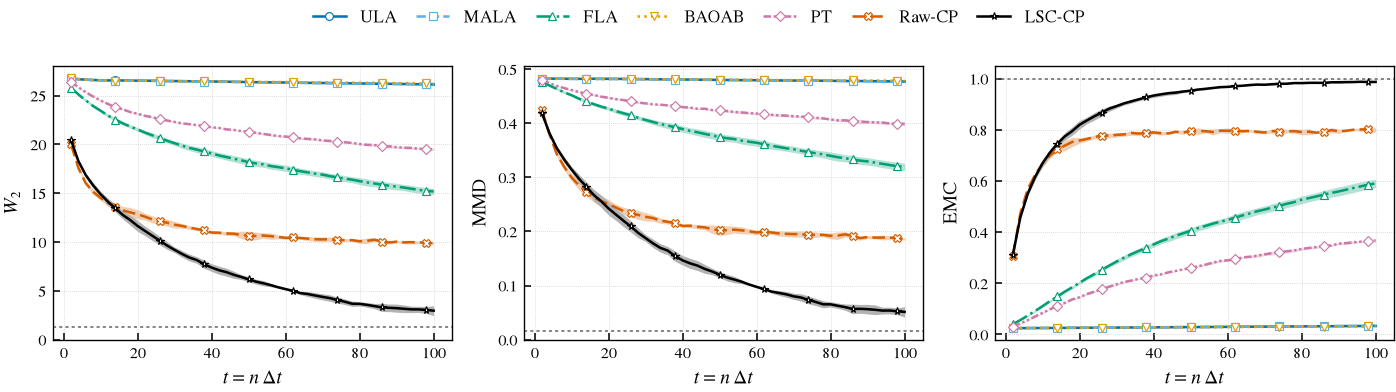

saved: /home/zheyuanlai/levy-sampling/JCP_experiments/figures/mog40/mog40_metrics.{png,pdf}


In [8]:
fig = metric_grid(rows, os.path.join(FIGURES, EXPERIMENT + "_metrics"),
                  metrics=("W2", "MMD", "EMC"), floors=floors,
                  emc_target=emc_target)
print("saved:", os.path.join(FIGURES, EXPERIMENT + "_metrics") + ".{png,pdf}")

In [9]:
# terminal exact-W2 spot check (Hungarian, 500-point subsample, 2D only)
gen_h = torch.Generator(device=DEV); gen_h.manual_seed(202)
ref_sub = exp.ref_sample(2500, gen_h)
from src.metrics import hungarian_w2
hungarian = {m: hungarian_w2(method_info[m]["final_positions_seed0"], ref_sub, m=500)
             for m in C.METHODS}
print("Hungarian W2:", {k: round(v, 3) for k, v in hungarian.items()})
ts_path = os.path.join(RESULTS, "metrics_timeseries.csv")
write_timeseries_csv(rows, ts_path)
summary_metrics = MAIN_METRICS + ["nonfinite_frac"]
summary = write_summary_csv(rows, C.METHODS, cfg.seeds, summary_metrics,
                            method_info, floors, os.path.join(RESULTS, "summary.csv"))

manifest = dict(
    experiment=EXPERIMENT,
    config=dict(d=cfg.d, N=cfg.n_particles, T=cfg.T, dt0=cfg.dt, dt=dt_final,
                beta=cfg.beta, eps=cfg.eps, lam=cfg.lam, seeds=list(cfg.seeds),
                n_checkpoints=C.N_CHECKPOINTS, warmup_steps=C.N_WARMUP_STEPS,
                batched_seeds=True),
    quadrature=dict(chosen=CHOSEN_QUAD, table=quad_table),
    dt_refinement=[{k: (str(v) if isinstance(v, tuple) else v) for k, v in row.items()}
                   for row in dt_table],
    pt_ladder={k: v for k, v in ladder_info.items()},
    certificate=cert_report,
    bias_floors=floors,
    barrier_verification=barrier_report,
    method_info={m: {k: v for k, v in mi.items() if isinstance(v, (int, float))}
                 for m, mi in method_info.items()},
    hardware=hardware_manifest(),
    hungarian_w2_terminal=hungarian,
)
write_manifest(os.path.join(RESULTS, "manifest.json"), **manifest)
print("wrote", ts_path)
from IPython.display import display
display(pd.read_csv(os.path.join(RESULTS, "summary.csv")).round(5))

Hungarian W2: {'ULA': 36.954, 'MALA': 36.917, 'FLA': 22.597, 'BAOAB': 37.131, 'PT': 29.005, 'CP': 15.094, 'LSC-CP': 6.338}


wrote /home/zheyuanlai/levy-sampling/JCP_experiments/results/mog40/metrics_timeseries.csv


,method,EMC_mean,EMC_std,MMD_mean,MMD_std,TV_mean,TV_std,V_evals_per_step,W2_mean,W2_std,...,jump_count_mean,m_clip_fraction,mala_accept,nonfinite_frac_mean,nonfinite_frac_std,pt_swap_accept,score_quad_evals_per_step,time_to_threshold_TV,wallclock_mean_s,wallclock_std_s
0,ULA,0.03362,0.00063,0.47709,0.00038,0.91800,0.00267,0.0,26.13046,0.02921,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,2.22935,0.0
1,MALA,0.03378,0.00054,0.47708,0.00013,0.91644,0.00266,12500.0,26.12838,0.01564,...,NaN,NaN,0.99995,0.0,0.0,NaN,0.0,inf,6.15047,0.0
2,FLA,0.59033,0.01609,0.31943,0.00672,0.43220,0.00987,0.0,15.17157,0.31160,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,3.27561,0.0
3,BAOAB,0.03155,0.00052,0.47846,0.00047,0.93092,0.00350,0.0,26.23086,0.02095,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,2.59067,0.0
4,PT,0.36736,0.00722,0.39872,0.00355,0.61004,0.00608,25000.0,19.48419,0.12850,...,NaN,NaN,0.99986,0.0,0.0,0.19227,0.0,inf,7.67021,0.0
5,CP,0.79966,0.00844,0.18567,0.00220,0.28292,0.01195,0.0,9.85602,0.09972,...,0.0099,NaN,NaN,0.0,0.0,NaN,0.0,inf,3.74273,0.0
6,LSC-CP,0.98724,0.00310,0.05126,0.00976,0.06540,0.01002,0.0,2.96394,0.50321,...,0.0099,0.0,NaN,0.0,0.0,NaN,0.0,64.0,1219.82124,0.0
